# Knowledge distillation: 86 M parametreli modelden 5 M parametreli modele

Bu notebook, `scripts/distill.py` içinde yapılan işi adım adım, küçük bir batch üzerinde gösterir.
Tam eğitim için script kullanılır; burada amaç **ne olduğunu görmek**.

**Problem:** Uçaktaki bilgisayar küçük. Konum bulmada kullandığımız model (DINOv2-base, fine-tune edilmiş)
86 milyon parametre. Daha küçük bir modelin aynı işi yapmasını istiyoruz.

**Fikir (öğretmen → öğrenci):** Büyük model (öğretmen) eğitilmiş ve iyi. Küçük modeli (öğrenci) sadece
"doğru cevap" ile değil, **öğretmenin nasıl düşündüğü** ile de eğitiriz. Öğretmen bize "bu drone görüntüsü şu uydu
karesine çok, şuna biraz, buna hiç benzemiyor" der; öğrenci bu dağılımı taklit eder.
Bu, tek bir doğru etiketten çok daha zengin bir bilgidir.

| model | parametre | test R@1<50 m |
|---|---|---|
| öğretmen: DINOv2-base (fine-tune + zor koşullar) | 86 M | 0.680 |
| MobileNetV3, öğretmensiz | 5 M | 0.614 |
| **MobileNetV3, distillation** | **5 M** | **0.684** |

In [1]:
import os, sys, random, json
from pathlib import Path
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
from gdnav.embed import load_embedder
from gdnav.student import StudentEmbedder
from gdnav.prepared import PreparedFlight
from scripts.train_finetune import Augment, batch_tensors, far_apart_batches

device = "cuda"
torch.manual_seed(0); rng = random.Random(0)
print(torch.cuda.get_device_name())

C:\Users\furkan_windows\miniconda3\envs\uav\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NVIDIA GeForce RTX 5090


## 1. Öğretmen ve öğrenci

* **Öğretmen:** Sprint 1'de fine-tune ettiğimiz DINOv2-base (zor koşul augmentasyonlu sürüm). Dondurulmuş, hiç değişmeyecek.
* **Öğrenci:** MobileNetV3-Large (ImageNet ile ön-eğitimli). Sonuna bir doğrusal katman ekledik: 512 boyutlu vektör üretir.

İkisi de bir görüntüyü bir **vektöre** (descriptor) çevirir. Benzer yerlerin vektörleri birbirine yakın olmalı.

In [2]:
teacher = load_embedder("facebook/dinov2-base", "cls+gem", "outputs/finetune/s1_robust/best.pt", device)
for p in teacher.parameters():
    p.requires_grad = False
student = StudentEmbedder("mobilenetv3", dim=512).to(device)

n_params = lambda m: sum(p.numel() for p in m.parameters()) / 1e6
x = torch.rand(2, 3, 224, 224, device=device)
with torch.no_grad():
    print(f"öğretmen: {n_params(teacher):5.1f} M parametre -> vektör boyutu {teacher(x).shape[1]}")
    print(f"öğrenci : {n_params(student):5.1f} M parametre -> vektör boyutu {student(x).shape[1]}")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:  40%|████      | 90/223 [00:00<00:00, 895.61it/s]

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 1409.12it/s]

öğretmen:  86.6 M parametre -> vektör boyutu 1536
öğrenci :   4.7 M parametre -> vektör boyutu 512


## 2. Veri: drone görüntüsü + aynı yerin uydu karesi

Her eğitim örneği bir **çift**: kuzeye çevrilmiş drone görüntüsü ve GPS etiketindeki konumdan kesilmiş uydu karesi.
Bir batch'teki görüntüler aynı uçuştan ama birbirinden en az 150 m uzak (yoksa iki "farklı" örnek aslında aynı yer olurdu).

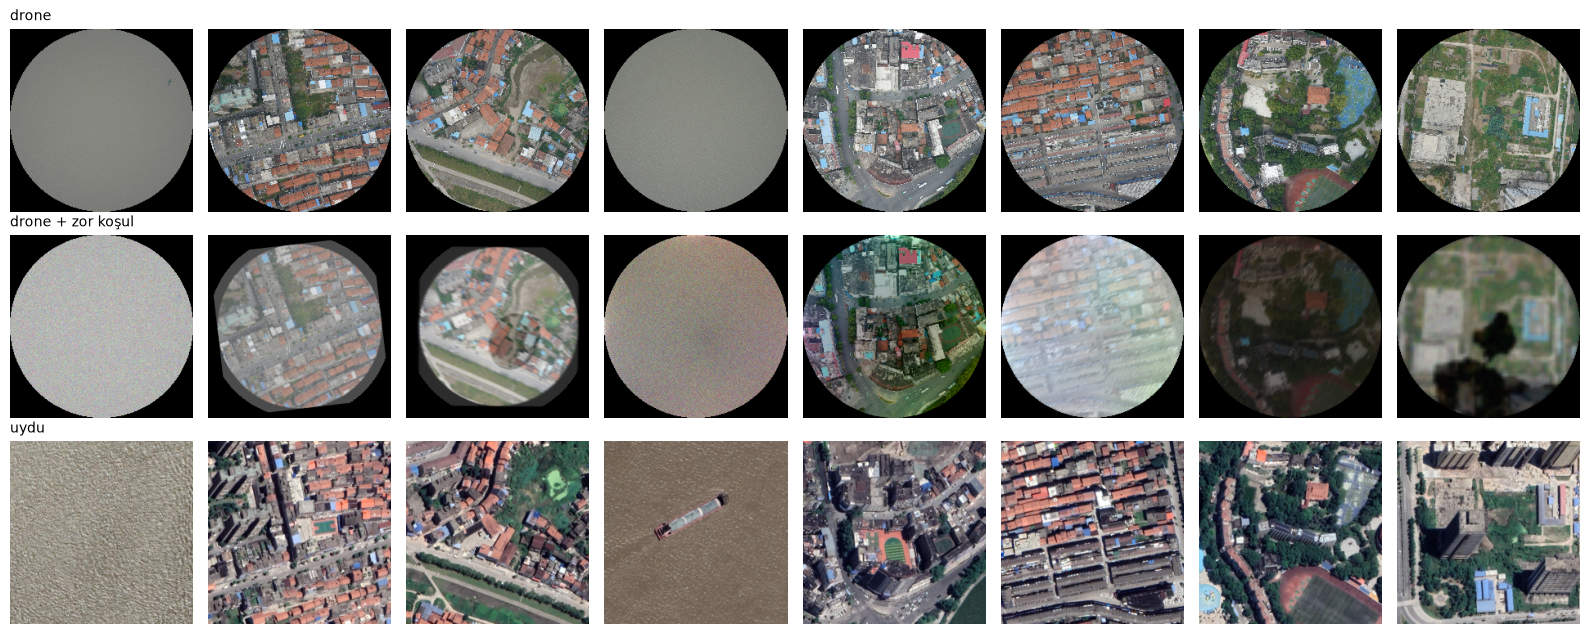

In [3]:
pf = PreparedFlight.load("01")                       # eğitim uçuşu (test uçuşları 03, 04, 11 hiç kullanılmaz)
idx = next(far_apart_batches(pf, 16, 150.0, rng))[:8]
q, s = batch_tensors(pf, idx, 15.0, rng, device)     # q: drone, s: uydu
aug = Augment(pf.px, 5.0, "robust").to(device)
qa, sa = aug(q, s)                                   # zor koşullar: bulut, karanlık, bulanıklık, JPEG ...

show = lambda t: t.permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(3, 8, figsize=(16, 6.4))
for i in range(8):
    for r, (t, name) in enumerate([(q, "drone"), (qa, "drone + zor koşul"), (s, "uydu")]):
        ax[r, i].imshow(show(t[i])); ax[r, i].axis("off")
        if i == 0: ax[r, i].set_title(name, loc="left", fontsize=10)
plt.tight_layout()

## 3. Öğretmen dünyayı nasıl görüyor? Benzerlik matrisi

8 drone görüntüsü × 8 uydu karesi arasındaki benzerlik (kosinüs). Satır *i*, sütun *i* aynı yer.
İyi bir model için **köşegen parlak**, geri kalanı koyu olmalı.

Eğitilmemiş öğrencinin matrisi karışık: henüz drone ile uyduyu eşleştiremiyor.

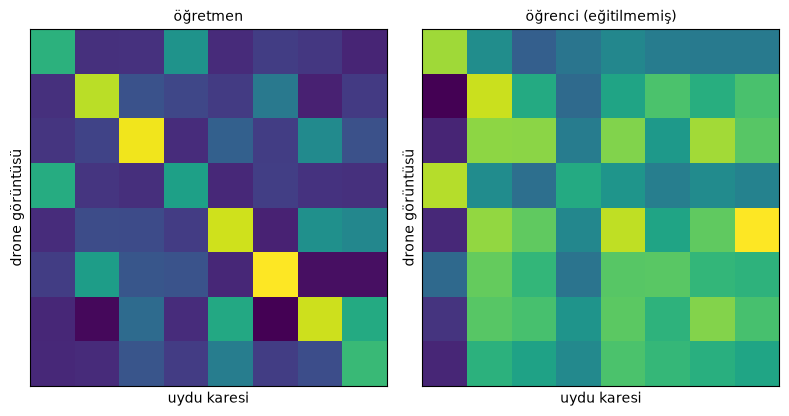

In [4]:
with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
    tq, ts = teacher(qa).float(), teacher(sa).float()
    sq, ss = student(qa).float(), student(sa).float()

def sim_plot(ax, a, b, title):
    m = (a @ b.T).cpu().numpy()
    ax.imshow(m, cmap="viridis"); ax.set_title(title, fontsize=10)
    ax.set_xlabel("uydu karesi"); ax.set_ylabel("drone görüntüsü")
    ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
sim_plot(ax[0], tq, ts, "öğretmen")
sim_plot(ax[1], sq, ss, "öğrenci (eğitilmemiş)")
plt.tight_layout()

## 4. Üç kayıp (loss) fonksiyonu

Toplam kayıp = **görev kaybı** + **ilişki kaybı** + **özellik kaybı**. Distillation'ın kalbi bu üç satır.

### 4a. Görev kaybı (InfoNCE): öğretmen olmadan da kullanılan kayıp
"Drone *i*, uydu *i* ile eşleşsin; diğer uydu kareleriyle değil." Benzerlik matrisinin her satırı bir sınıflandırma
problemi gibi: doğru sınıf köşegen.

In [5]:
temp = 0.07
logits = sq @ ss.T / temp
target = torch.arange(len(sq), device=device)
l_task = (F.cross_entropy(logits, target) + F.cross_entropy(logits.T, target)) / 2
print(f"görev kaybı: {l_task.item():.3f}   (rastgele tahmin ≈ ln(8) = {np.log(8):.3f})")

görev kaybı: 1.429   (rastgele tahmin ≈ ln(8) = 2.079)


### 4b. İlişki kaybı (relational KD): öğretmenden gelen asıl bilgi

Görev kaybı sadece "doğru olan hangisi" der. Öğretmen ise **tüm sıralamayı** bilir: drone görüntüsü 3 belki uydu
karesi 5'e de biraz benziyor (ikisi de tarla). Öğrenciden bu **benzerlik dağılımını** taklit etmesini isteriz.

Batch'teki tüm görüntüler (drone + uydu + etiketsiz ekstra uydu kareleri) için öğretmenin ve öğrencinin benzerlik
matrisleri çıkarılır, her satır softmax ile olasılığa çevrilir ve iki dağılım arasındaki **KL divergence**
küçültülür. Retrieval için önemli olan vektörlerin kendisi değil **sıralama** olduğu için bu kayıp çok uygun.

*Bonus:* Ekstra uydu kareleri için etiket gerekmez; harita bedava veri. Öğretmen onlara da "not verir".

ilişki kaybı (KL): 2.236


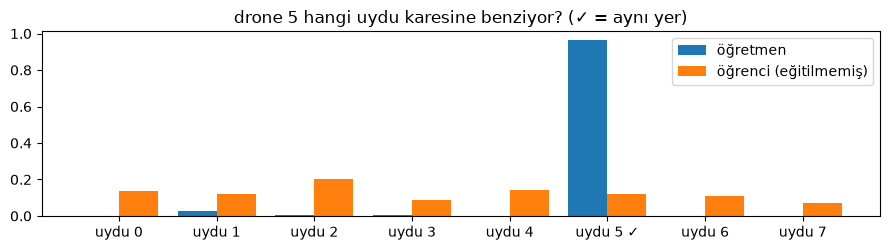

In [6]:
imgs = torch.cat([qa, sa])
with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
    et = teacher(imgs).float()
    es = student(imgs).float()
tau = 0.05
eye = torch.eye(len(imgs), dtype=torch.bool, device=device)     # kendisiyle benzerliği sayma
st = (et @ et.T / tau).masked_fill(eye, -1e4)
ss_ = (es @ es.T / tau).masked_fill(eye, -1e4)
l_rel = F.kl_div(F.log_softmax(ss_, 1), F.log_softmax(st, 1), log_target=True, reduction="batchmean")
print(f"ilişki kaybı (KL): {l_rel.item():.3f}")

# bir drone görüntüsü için "hangi uydu karesine benziyorum" dağılımı (görüntü için tau=0.1)
n = len(qa)
P_t = F.softmax(et[:n] @ et[n:].T / 0.1, 1).cpu().numpy()
P_s = F.softmax(es[:n] @ es[n:].T / 0.1, 1).cpu().numpy()
i = int(np.abs(P_t - P_s).sum(1).argmax())          # öğretmen ile öğrencinin en çok ayrıştığı drone görüntüsü
fig, ax = plt.subplots(figsize=(9, 2.6))
xs = np.arange(n)
ax.bar(xs - 0.2, P_t[i], 0.4, label="öğretmen"); ax.bar(xs + 0.2, P_s[i], 0.4, label="öğrenci (eğitilmemiş)")
ax.set_xticks(xs, [f"uydu {k}" + (" ✓" if k == i else "") for k in range(n)])
ax.set_title(f"drone {i} hangi uydu karesine benziyor? (✓ = aynı yer)"); ax.legend()
plt.tight_layout()

### 4c. Özellik kaybı (feature KD)
Öğrencinin 512 boyutlu vektörü küçük bir doğrusal katmanla 1536 boyuta çıkarılır ve öğretmenin vektörüne
yaklaştırılır (kosinüs). Bu katman **sadece eğitimde** var, sonra atılır. Öğrenciye ek bir "ipucu" sinyali verir.

In [7]:
proj = torch.nn.Linear(512, et.shape[1]).to(device)
l_feat = (1 - F.cosine_similarity(proj(es), et, dim=1)).mean()
print(f"özellik kaybı: {l_feat.item():.3f}")
print(f"TOPLAM = görev {l_task.item():.2f} + ilişki {l_rel.item():.2f} + özellik {l_feat.item():.2f}")

özellik kaybı: 0.999
TOPLAM = görev 1.43 + ilişki 2.24 + özellik 1.00


## 5. Mini eğitim (sadece birkaç dakika)

Tam eğitim `scripts/distill.py` ile 25 epoch sürer (~5 dk). Burada aynı döngüyü 80 adım çalıştırıp
kayıpların düştüğünü görelim. Her adımda: batch al → zor koşul uygula → öğretmen ve öğrenci vektörleri →
3 kayıp → geri yayılım.

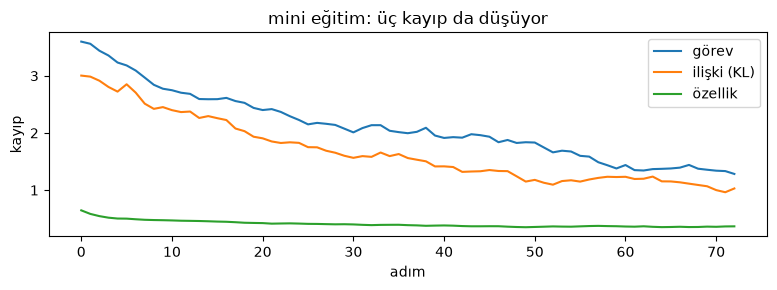

In [8]:
train = [PreparedFlight.load(f) for f in ["01", "02", "05", "08", "09", "10"]]
student = StudentEmbedder("mobilenetv3", dim=512).to(device)
proj = torch.nn.Linear(512, 1536).to(device)
log_t = torch.nn.Parameter(torch.tensor(np.log(1 / 0.07), device=device, dtype=torch.float32))
opt = torch.optim.AdamW([{"params": student.backbone.parameters(), "lr": 3e-4},
                         {"params": list(student.head.parameters()) + list(proj.parameters()) + [log_t], "lr": 1e-3}],
                        weight_decay=0.05)
hist = []
student.train()
for step in range(80):
    pf = random.choice(train)
    idx = next(far_apart_batches(pf, 64, 150.0, rng))
    q, s = aug(*batch_tensors(pf, idx, 15.0, rng, device))
    imgs, n = torch.cat([q, s]), len(idx)
    with torch.autocast("cuda", dtype=torch.bfloat16):
        es = student(imgs).float()
        with torch.no_grad():
            et = teacher(imgs).float()
    logits = log_t.exp() * es[:n] @ es[n:].T
    tgt = torch.arange(n, device=device)
    l_task = (F.cross_entropy(logits, tgt) + F.cross_entropy(logits.T, tgt)) / 2
    eye = torch.eye(len(imgs), dtype=torch.bool, device=device)
    l_rel = F.kl_div(F.log_softmax((es @ es.T / tau).masked_fill(eye, -1e4), 1),
                     F.log_softmax((et @ et.T / tau).masked_fill(eye, -1e4), 1), log_target=True, reduction="batchmean")
    l_feat = (1 - F.cosine_similarity(proj(es), et, dim=1)).mean()
    loss = l_task + l_rel + l_feat
    opt.zero_grad(); loss.backward(); opt.step()
    hist.append([l_task.item(), l_rel.item(), l_feat.item()])

h = np.array(hist)
plt.figure(figsize=(8, 3))
for k, name in enumerate(["görev", "ilişki (KL)", "özellik"]):
    plt.plot(np.convolve(h[:, k], np.ones(8) / 8, "valid"), label=name)
plt.xlabel("adım"); plt.ylabel("kayıp"); plt.legend(); plt.title("mini eğitim: üç kayıp da düşüyor")
plt.tight_layout()

## 6. Tam eğitilmiş öğrenciler

`scripts/distill.py` ile eğitilmiş iki MobileNetV3'ü yükleyelim: biri öğretmenle (distillation), biri öğretmensiz
(sadece görev kaybı). Aynı 8 çiftteki benzerlik matrislerine bakalım.

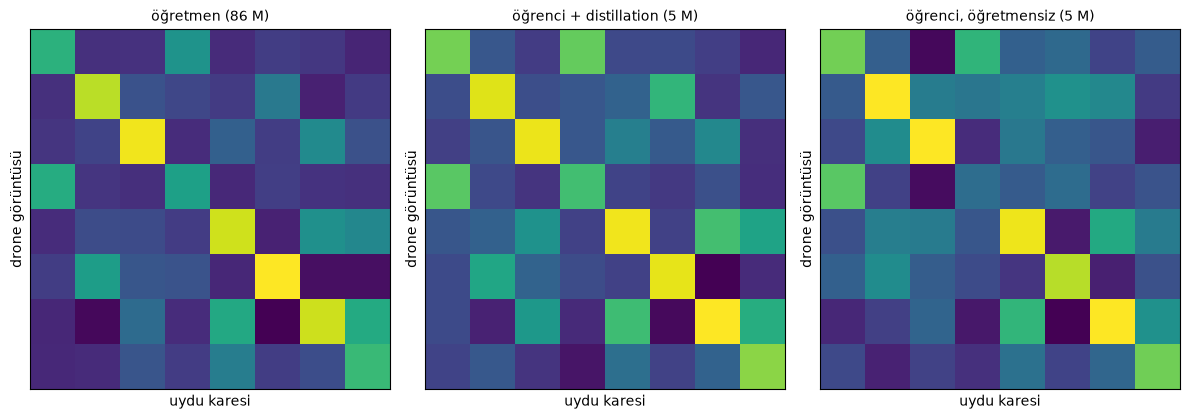

In [9]:
kd = load_embedder("", "", "outputs/distill/mnv3_kd/best.pt", device)
nokd = load_embedder("", "", "outputs/distill/mnv3_nokd/best.pt", device)
with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
    pairs = [(teacher, "öğretmen (86 M)"), (kd, "öğrenci + distillation (5 M)"), (nokd, "öğrenci, öğretmensiz (5 M)")]
    embs = [(m(qa).float(), m(sa).float(), t) for m, t in pairs]
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (e1, e2, t) in zip(ax, embs):
    sim_plot(a, e1, e2, t)
plt.tight_layout()

## 7. Öğretmen gerçekten işe yaradı mı?

Doğrulama uçuşunda (06) her epoch sonunda ölçülen başarı (R@1 < 50 m: en benzer uydu karesi doğru yerden 50 m içinde mi).
Öğretmenli eğitim her iki öğrencide de belirgin şekilde önde.

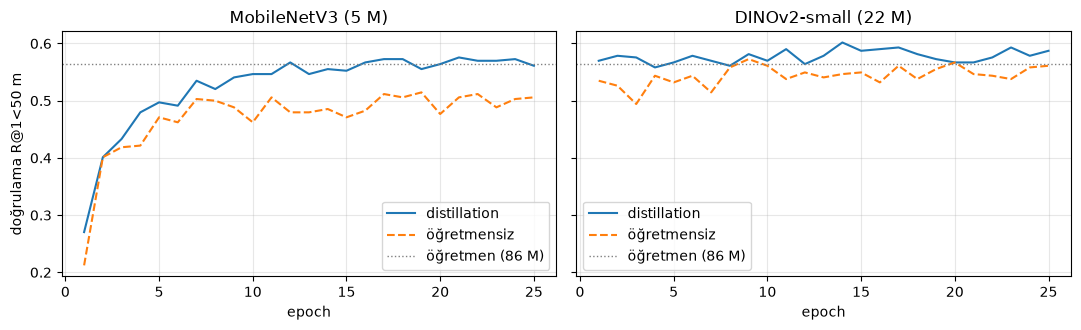

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for a, arch, title in [(ax[0], "mnv3", "MobileNetV3 (5 M)"), (ax[1], "vits", "DINOv2-small (22 M)")]:
    for kind, style in [("kd", "-"), ("nokd", "--")]:
        h = json.load(open(f"outputs/distill/{arch}_{kind}/history.json"))["history"]
        a.plot([r["epoch"] for r in h], [r["R@1<50m"] for r in h], style,
               label="distillation" if kind == "kd" else "öğretmensiz")
    a.axhline(0.564, color="gray", lw=1, ls=":", label="öğretmen (86 M)")
    a.set_title(title); a.set_xlabel("epoch"); a.legend(); a.grid(alpha=.3)
ax[0].set_ylabel("doğrulama R@1<50 m")
plt.tight_layout()

In [11]:
# test uçuşları (03, 04, 11 - eğitimde hiç görülmedi), 2096 görüntü
rows = [("öğretmen DINOv2-base", "test_kd_ft_robust", 86.6), ("DINOv2-small, öğretmensiz", "test_kd_vits_nokd", 22.6),
        ("DINOv2-small, distillation", "test_kd_vits", 22.6), ("MobileNetV3, öğretmensiz", "test_kd_mnv3_nokd", 4.7),
        ("MobileNetV3, distillation", "test_kd_mnv3", 4.7)]
print(f"{'model':30s} {'param':>7s} {'R@1<50m':>8s} {'R@10<50m':>9s}")
for name, tag, p in rows:
    fl = json.load(open(f"outputs/eval/{tag}/summary.json"))["flights"]
    n = sum(v["n_queries"] for v in fl.values())
    r1 = sum(v["R@1<50m"] * v["n_queries"] for v in fl.values()) / n
    r10 = sum(v["R@10<50m"] * v["n_queries"] for v in fl.values()) / n
    print(f"{name:30s} {p:6.1f}M {r1:8.3f} {r10:9.3f}")

model                            param  R@1<50m  R@10<50m
öğretmen DINOv2-base             86.6M    0.680     0.927
DINOv2-small, öğretmensiz        22.6M    0.645     0.917
DINOv2-small, distillation       22.6M    0.689     0.942
MobileNetV3, öğretmensiz          4.7M    0.614     0.898
MobileNetV3, distillation         4.7M    0.684     0.917


## Özet

* Distillation kodu zor değil: öğretmen dondurulur, aynı batch iki modelden geçer, **3 kayıp toplanır**.
  Asıl fikir ~15 satır (`scripts/distill.py`, eğitim döngüsü).
* Kritik tasarım kararları:
  1. **İlişki kaybı:** Retrieval sıralama işidir, bu yüzden öğrenci öğretmenin vektörlerini değil
     **benzerlik yapısını** taklit eder.
  2. **Etiketsiz ekstra uydu kareleri:** Harita bedava veri; öğretmen bunlara da not verir.
  3. **Adil karşılaştırma:** Aynı öğrenci öğretmensiz de eğitildi. Fark (+4 ile +7 puan) distillation'ın katkısı.
  4. **Test uçuşları eğitimde hiç kullanılmadı** (bölge bazlı ayrım).

### Mülakatta sorulabilecekler
* *Öğrenci neden öğretmeni geçebiliyor?* Öğrencinin tüm katmanları eğitildi (öğretmende sadece son 4 blok),
  etiketsiz uydu kareleri ve öğretmenin yumuşak hedefleri bir tür düzenleyici (regularizer) görevi görüyor.
  Ama test farkı küçük (0.684 vs 0.680); doğru ifade "**öğretmen seviyesinde**".
* *Neden MSE değil de KL?* Retrieval'da vektörlerin mutlak değeri değil, kime daha yakın olduğu önemli.
  KL, satır bazında sıralamayı/dağılımı aktarır.
* *Uçakta ne kazandırıyor?* 17× daha az parametre, 3× daha küçük harita veritabanı (512 vs 1536 boyut),
  CPU'da çalışabilir hız. Gömülü kartta (Jetson) ölçüm bir sonraki adım.